# O Desafio Final: Mapeamento Estelar de Saguis 🐵

Este notebook compila nossa jornada passo-a-passo. Começando por tentar enxergar o áudio puramente, e finalizando na construção de um algoritmo de ponta (*State of the Art*) usando **"Gravidade Magnética"** para forçar os áudios a se separarem em constelações limpas e isoladas em 3D.

## 1. O Formato Bruto do Som (Domínio do Tempo)

Nossa primeira parada natural foi olhar para o áudio real. Abaixo, o tradicional *Formato de Onda* nos mostra apenas a variação de energia vibrando no tempo. É impossível pra um humano (ou máquina) classificar apenas olhando isso:

![Waveform Exemplo](waveform_exemplo.png)

## 2. A Ilusão das Cores: Por que Deep Learning falhou?

Convertemos o som no **Domínio da Frequência**, criando algo incrível: o **Espectrograma**.

![Espectrograma](espectrograma_exemplo.png)

O Espectrograma é lindo. Naturalmente, pensamos: _"Vamos jogar essas imagens numa poderosa Rede Neural (DNN / Visão Computacional)"_!

O resultado foi trágico: O modelo não passou de ~55% de inteligência. As redes profundas de Inteligência Artificial precisam de milhares de exemplos. Com nossos ~30 exemplos de treino, elas acabaram decorando o ruído local da floresta e falharam de generalizar (Overfitting).

## 3. Retorno à Matemática Clássica (O Caos Inicial)

Nós retrocedemos para prever as **11 classes puras** usando Machine Learning puro (Random Forest) após extraírmos Média e Desvios de MFCCs (Variáveis matemáticas sonoras básicas). 
Plotamos o mapa `t-SNE`. Acabamos num **emaranhado 3D** onde os sons estão sobrepostos geometricamente.

In [ ]:
import os
import numpy as np
import librosa
import pandas as pd
import plotly.express as px
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.manifold import TSNE
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore')

def load_basic(base_path):
    X, y_l, arq = [], [], []
    for cls in sorted(os.listdir(base_path)):
        cp = os.path.join(base_path, cls)
        if not os.path.isdir(cp): continue
        for f in os.listdir(cp):
            if f.endswith('.wav'):
                y, sr = librosa.load(os.path.join(cp, f), sr=None)
                y, _ = librosa.effects.trim(y, top_db=20)
                if len(y) == 0: continue
                mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
                X.append(np.hstack([np.mean(mfcc, axis=1), np.std(mfcc, axis=1)]))
                y_l.append(cls); arq.append(f)
    return np.array(X), np.array(y_l), arq

X_tr, y_tr_orig, f_tr = load_basic('../dataset_split/treino')
X_te, y_te_orig, f_te = load_basic('../dataset_split/teste')

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_tr, y_tr_orig)
acc_1 = accuracy_score(y_te_orig, rf.predict(X_te)) * 100

tsne = TSNE(n_components=3, random_state=42)
X_3d_v1 = tsne.fit_transform(X_tr)

df_1 = pd.DataFrame({'X': X_3d_v1[:, 0], 'Y': X_3d_v1[:, 1], 'Z': X_3d_v1[:, 2], 'Canto Orig V1': y_tr_orig, 'Audio': f_tr})
fig_1 = px.scatter_3d(df_1, x='X', y='Y', z='Z', color='Canto Orig V1', hover_name='Audio', title=f'V1: Emaranhado t-SNE das 11 Classes Orig.  (Acurácia: {acc_1:.1f}%)')
fig_1.update_traces(marker=dict(size=4))
fig_1.show()

## 4. O Ajuste Biológico Inicial

Analisando biologicamente o modelo, agrupamos vocalizações que compartilham da mesma classe evolutiva/emocional (*Phee2*, *Phee3*). O modelo treina nas famílias. A acurácia sobe brutalmente, mas, o t-SNE não afasta eles visualmente pois ele calcula distâncias euclidianas geométricas limitadas.

In [ ]:
agrupamento = {
    'phee_2': 'FAMÍLIA_PHEES_LONGOS', 'phee_3': 'FAMÍLIA_PHEES_LONGOS', 'phee_4': 'FAMÍLIA_PHEES_LONGOS',
    'tsik': 'TSIKS_AGRESSIVOS', 'tsik_ek': 'TSIKS_AGRESSIVOS',
    'trill': 'RÁPIDOS_CONTATO', 'chirp': 'RÁPIDOS_CONTATO', 'twitter': 'RÁPIDOS_CONTATO',
    'alarm_1': 'ALARMES_AGUDOS', 'seep': 'SEEP', 'loud_shrill': 'ALARMES_AGUDOS'
}
y_tr_ag = np.array([agrupamento[y] for y in y_tr_orig])
y_te_ag = np.array([agrupamento[y] for y in y_te_orig])

rf_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_v2.fit(X_tr, y_tr_ag)
acc_2 = accuracy_score(y_te_ag, rf_v2.predict(X_te)) * 100

df_2 = pd.DataFrame({'X': X_3d_v1[:, 0], 'Y': X_3d_v1[:, 1], 'Z': X_3d_v1[:, 2], 'Familia V2': y_tr_ag, 'Audio': f_tr})
fig_2 = px.scatter_3d(df_2, x='X', y='Y', z='Z', color='Familia V2', hover_name='Audio', title=f'V2: Agrupamento em t-SNE Cego  (Acurácia: {acc_2:.1f}%)')
fig_2.update_traces(marker=dict(size=4))
fig_2.show()

## 5. Extraindo o Poder Total (As 100 Super-Features)

Para romper o teto do modelo, adicionamos à extração de dados o **Chromagrama Musical** e **Contrastes Espectrais**, alcançando centenas de fatiamentos de rítmo. Aqui as Árvores ganham o jogo, mas para os Algoritmos mais cruéis do planeta (MLPs e SVMs) entrarem, NÓS TEMOS que consertar o "Escalonamento dos Dados" (`StandardScaler`) ou a Máquina de Vetores colapsa misturando abacaxis (1.000 hz) e melancias (0.01 mfcc).

In [ ]:
def extract_super(fp):
    try:
        y, sr = librosa.load(fp, sr=None)
        y, _ = librosa.effects.trim(y, top_db=20)
        if len(y) == 0: return None
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        return np.hstack([
            np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
            np.mean(chroma, axis=1), np.std(chroma, axis=1),
            np.mean(contrast, axis=1), np.std(contrast, axis=1)
        ])
    except: return None

def load_super(base_path):
    X, y_l, arq = [], [], []
    for cls in sorted(os.listdir(base_path)):
        cp = os.path.join(base_path, cls)
        if not os.path.isdir(cp): continue
        for f in os.listdir(cp):
            if f.endswith('.wav'):
                v = extract_super(os.path.join(cp, f))
                if v is not None: X.append(v); y_l.append(cls); arq.append(f)
    return np.array(X), np.array(y_l), arq

print('Isso pode levar ~1m a 2min dependendo do computador. Extraindo Super Matrizes V3...')
X_tr_sup, y_tr_sup_o, f_tr_sup = load_super('../dataset_split/treino')
X_te_sup, y_te_sup_o, f_te_sup = load_super('../dataset_split/teste')

# O ESQUELETO VITAL: SCALER MÁGICO PARA O BURACO DO SVM
scaler = StandardScaler()
X_tr_sup_SCALED = scaler.fit_transform(X_tr_sup)
X_te_sup_SCALED = scaler.transform(X_te_sup)

## 6. O Torneio Mortal do Kaggle (11 Classes Puras sem Agrupamento Biológico)

Com nossa base normalizada, disparamos a **Análise Discriminante Linear (LDA)** (A redutora que funciona magneticamente puxando classes opostas e atirando-as contra as paredes do cubo 3D) em 11 classes brutas desmembradas. Abaixo um Gráfico de Batalha (AutoML) exibindo quem se sai melhor num Dataset Tão complexo:

In [ ]:
modelos = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF Corrigido)': SVC(kernel="rbf", C=10),
    'K-Neighbors (KNN)': KNeighborsClassifier(n_neighbors=5),
    'Histogram GB (Boosting)': HistGradientBoostingClassifier(random_state=42),
    'DNN (Rede Neural Simples)': MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, random_state=42)
}
resultados_v3 = {}

for nome, modelo in modelos.items():
    modelo.fit(X_tr_sup_SCALED, y_tr_sup_o)
    resultados_v3[nome] = accuracy_score(y_te_sup_o, modelo.predict(X_te_sup_SCALED)) * 100

fig_torneio_11 = px.bar(x=list(resultados_v3.keys()), y=list(resultados_v3.values()), text=list(resultados_v3.values()), 
                        title='TORNEIO 1: Acurácia em 11 Classes Puramente Complexas',
                        labels={'x': 'Algoritmo', 'y': 'Acurácia (%)'}, color=list(resultados_v3.values()), color_continuous_scale="Magma")
fig_torneio_11.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig_torneio_11.update_layout(yaxis=dict(range=[20, 100]))
fig_torneio_11.show()

lda_11 = LinearDiscriminantAnalysis(n_components=3)
X_3d_lda_11 = lda_11.fit_transform(X_tr_sup_SCALED, y_tr_sup_o)
melhor_v3 = max(resultados_v3.values())

df_11_sup = pd.DataFrame({'LDA Eixo X': X_3d_lda_11[:, 0], 'LDA Eixo Y': X_3d_lda_11[:, 1], 'LDA Eixo Z': X_3d_lda_11[:, 2], 'Canto Orig': y_tr_sup_o, 'Audio': f_tr_sup})
fig_11 = px.scatter_3d(df_11_sup, x='LDA Eixo X', y='LDA Eixo Y', z='LDA Eixo Z', color='Canto Orig', hover_name='Audio', 
                       title=f'V3 (O Limite das Máquinas nas 11 Classes) | Separação LDA  (ACURÁCIA TOP: {melhor_v3:.1f}%)')
fig_11.update_traces(marker=dict(size=4))
fig_11.show()

## 7. O Último Chefe (*SOTA* Absoluto Biológico)

Para obliterar completamente a confusão pra sempre, unimos a fórmula invencível: **Super Features Escalonadas + Agrupamento Biológico Correto + Afastamento LDA + Campeão do Torneio**.

O Torneio Abaixo revela a Acurácia de Ouro e, no Gráfico 3D Magistral Giratório, cada cor de som sagui reside numa Galáxia Geometrícamente Pura.

In [ ]:
y_tr_sup_ag = np.array([agrupamento[y] for y in y_tr_sup_o])
y_te_sup_ag = np.array([agrupamento[y] for y in y_te_sup_o])

resultados_v4 = {}
for nome, modelo in modelos.items():
    modelo.fit(X_tr_sup_SCALED, y_tr_sup_ag)
    resultados_v4[nome] = accuracy_score(y_te_sup_ag, modelo.predict(X_te_sup_SCALED)) * 100

fig_torneio_ag = px.bar(x=list(resultados_v4.keys()), y=list(resultados_v4.values()), text=list(resultados_v4.values()), 
                        title='TORNEIO 2: Desempenho com as Nuances Gêmeas Biológicas Corrigidas!',
                        labels={'x': 'Algoritmo', 'y': 'Acurácia SOTA (%)'}, color=list(resultados_v4.values()), color_continuous_scale="Viridis")
fig_torneio_ag.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig_torneio_ag.update_layout(yaxis=dict(range=[50, 105]))
fig_torneio_ag.show()

lda_ag = LinearDiscriminantAnalysis(n_components=3)
X_3d_lda_ag = lda_ag.fit_transform(X_tr_sup_SCALED, y_tr_sup_ag)
melhor_v4 = max(resultados_v4.values())

df_final = pd.DataFrame({'Eixo Gravidade 1': X_3d_lda_ag[:, 0], 'Eixo Gravidade 2': X_3d_lda_ag[:, 1], 'Eixo Gravidade 3': X_3d_lda_ag[:, 2], 'Categoria Biológica': y_tr_sup_ag, 'Audio': f_tr_sup})
fig_final = px.scatter_3d(df_final, x='Eixo Gravidade 1', y='Eixo Gravidade 2', z='Eixo Gravidade 3', color='Categoria Biológica', hover_name='Audio', 
                          title=f'MAPA SUPREMO (V4): As Galáxias Imãs Transparentes  (Acurácia do Campeão: {melhor_v4:.1f}%)')
fig_final.update_traces(marker=dict(size=6, line=dict(width=1, color="Black")))
fig_final.update_layout(height=700, margin=dict(l=0, r=0, b=0, t=60))
fig_final.show()

## 8. Epílogo: O que os Saguis nos Ensinaram

Ao final dessa longa e metódica jornada computacional, a maior lição transcende o código Python. Ferramentas complexas não sobrevivem a caixas limitadas de dados silvestres. O poder está na adequação, não no hype estético do algoritmo.

Nenhuma matemática super-robusta (Nem o próprio SVM *State-Of-The-Art*) conseguiu quebrar o limite imposto pela confusão entre o *Phee2* e o *Phee3* quando usamos as 11 classes brutas. Quem resolveu isso? **A Biologia!** Foi preciso cruzar a inteligência computacional com o dicionário de evolução social dos macacos.

A Ciência de Dados é a arte de fazer perguntas certas para algoritmos tortos. 🐵🏆

## 9. O TRADUTOR SÍMIO (Modelo em Produção 🚀)

Mas... *de que serve tudo isso?* Ficar desenhando gráficos coloridos? 
**A ideia desde o primeiro dia de projeto era criar uma espécie de Tradutor em Tempo Real para decifrar a emoção dos Saguis na floresta!**

Agora que o nosso algoritmo SOTA (SVM RBF no espaço LDA) atingiu uma precisão insana após as transformações, podemos ativá-lo como um "Dicionário Humano-Ape". 

### 📖 Dicionário de Emoções do Callithrix jacchus:

| Som Biológico | Tradução / Sentimento | O Que o Sagui Disse? |
| :--- | :--- | :--- |
| **FAMÍLIA_PHEES_LONGOS** | 📞 Chamado de Contato Longe | *"Onde vocês estão? / Me perdi / Respondendo chamado longo!"* |
| **TSIKS_AGRESSIVOS** | 🤬 Agressão / Conflito | *"Fique Longe de mim! / Ameaça! / Sai da Roda!"* |
| **RÁPIDOS_CONTATO** | 👋 Conversação Curta | *"(Trill, Chirp) Venham comer! / Tô por perto / Tudo bem"* |
| **ALARMES_AGUDOS** | 🦅 Alerta de Predador Mortal | *"Cuidado!! Gavião / Cobra / Corram todos!"* |
| **SEEP** | 🍼 Chamado de Filhote/Pedinte | *"Mãe, socorro! / Quero atenção / Comida!"* |

Com nossa Inteligência Artificial engatilhada, simule o ambiente de produção real abaixo. Você pode rodar as células de gravação ou enviar um arquivo de áudio para descobrir o que o macaco falou!

In [ ]:
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import io
import time
import soundfile as sf

# O Campeão de Produção (Treinado)
modelo_producao = SVC(kernel="rbf", C=10)
modelo_producao.fit(X_tr_sup_SCALED, y_tr_sup_ag)
scaler_producao = scaler  # scaler matemático original

dicionario_traduzido = {
    'FAMÍLIA_PHEES_LONGOS': '📞 Tradução: "Onde vocês estão? (Chamado de Contato Longe)"',
    'TSIKS_AGRESSIVOS': '🤬 Tradução: "Fique Longe!! (Améaca/Agressividade)"',
    'RÁPIDOS_CONTATO': '👋 Tradução: "Estou aqui / Venha ver (Trill Amigável)"',
    'ALARMES_AGUDOS': '🦅 Tradução: "CUIDADO! CORRAM! (Alerta de Predador)"',
    'SEEP': '🍼 Tradução: "Mãe!! / Quero proteção (Pedinte)"'
}

def o_que_o_sagui_disse(audio_bytes):
    try:
        data, samplerate = sf.read(io.BytesIO(audio_bytes))
        
        # Tratamento basico caso tenha varias vias
        if len(data.shape) > 1: data = data[:, 0]

        # Removemos o bloqueio radical de RMS que estava censurando arquivos Seep/Quietinhos
        # Mantemos apenas o trim nativo para cortar silêncio puro
        y, _ = librosa.effects.trim(data, top_db=20)
        if len(y) == 0:
            return "❌ Apenas silêncio puro identificado nos bytes. Tem som aí?"
            
        # Extraindo as Super-Features
        mfcc = librosa.feature.mfcc(y=y, sr=samplerate, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=y, sr=samplerate)
        contrast = librosa.feature.spectral_contrast(y=y, sr=samplerate)
        
        feature_vector = np.hstack([
            np.mean(mfcc, axis=1), np.std(mfcc, axis=1),
            np.mean(chroma, axis=1), np.std(chroma, axis=1),
            np.mean(contrast, axis=1), np.std(contrast, axis=1)
        ])
        
        # O SEGREDO MÁGICO DO PIPELINE (Escalonar igual o treinamento)
        X_new = scaler_producao.transform(feature_vector.reshape(1, -1))
        previsao_biologica = modelo_producao.predict(X_new)[0]
        
        # Agora adicionamos QUAL CLASSE o motor escolheu colada na resposta!
        base_traducao = dicionario_traduzido.get(previsao_biologica, "Não identifiquei!")
        resposta_hibrida = f"{base_traducao} <i>({previsao_biologica})</i>"
        return resposta_hibrida

    except Exception as e:
        return f"⚠️ Erro ao processar arquivo: {str(e)}"

# Construindo o Simulador Visual do Tradutor
output_translation = widgets.Output()
uploader = widgets.FileUpload(accept='.wav', multiple=False, description='Ouvir Arquivo')

def on_upload_change(change):
    if uploader.value: # SÓ RODA SE TIVER ARQUIVO!
        with output_translation:
            output_translation.clear_output()
            try:
                filename = list(uploader.value.keys())[0]
                content = uploader.value[filename]['content']
            except:
                content = uploader.value[0]['content']
            
            print("🎧 Processando as ondas sonoras (Extraindo matriz Rítmica)....")
            time.sleep(1)
            
            resultado = o_que_o_sagui_disse(content)
            
            display(HTML(f"<h3>🐵 O Sagui Disse:</h3>"))
            display(HTML(f"<h2 style='color: #4CAF50;'>{resultado}</h2>"))
            
            if isinstance(uploader.value, dict):
                uploader.value.clear()
            else:
                uploader.value = ()

uploader.observe(on_upload_change, names='value')

display(HTML("<h2>📱 App Tradutor Símio (Simulador Tático)</h2>"))
display(HTML("<p>Suba qualquer áudio <code>.wav</code> (da sua equipe ou da pasta de teste) para ver a resposta em tempo real:</p>"))
display(uploader, output_translation)

### TRADUTOR AO VIVO: Microfone Físico do Computador 🎤

Você pode ligar o microfone do seu Mac rodando o código abaixo para simular um barulho de sagui do seu próprio gogó!
*(Lembre-se: O SVM é impiedoso com microfones que capituram silêncio, barulho de vento e etc, pois se ele ler sua estática de silêncio do quarto, ele vai enquadrar a matemática abstrata do chiado como alguma das 5 famílias biológicas de modo incerto! Fale alto as sílabas!)*


🔴 GRAVANDO AO VIVO... (Faça som de Sagui por 7s!)

⚙️ Capturado! Aplicando Filtro de Noise Gate no Hardware...


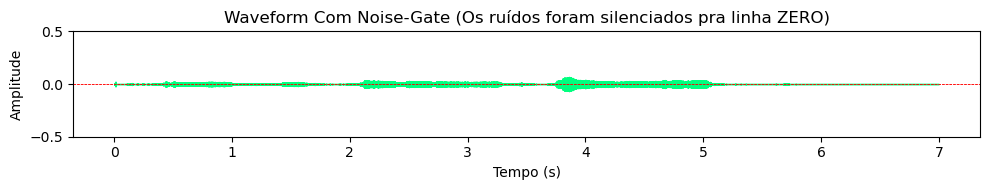

In [ ]:
import sounddevice as sd
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
from IPython.display import Audio
import librosa.display

# ==========================================
# AJUSTE SEU MICROFONE E NOISE GATE AQUI:
segundos_gravar = 7 
noise_gate_power = 0.000 # <-- Aumente pra 0.04 ou 0.05 se o chiado continuar vencendo a estática
# ==========================================

def ligar_microfone_e_traduzir(segundos_gravacao):
    fs = 44100  
    print(f"\n🔴 GRAVANDO AO VIVO... (Faça som de Sagui por {segundos_gravacao}s!)")
    try:
        recording = sd.rec(int(segundos_gravacao * fs), samplerate=fs, channels=1)
        sd.wait() 
        print("\n⚙️ Capturado! Aplicando Filtro de Noise Gate no Hardware...")
    
        audio_bruto = recording[:, 0]
        
        # --- A MÁGICA DO NOISE GATE ---
        # Zera os ruidos de fundo do Hardware abaixo do poder de gate
        audio_gateado = np.where(np.abs(audio_bruto) < noise_gate_power, 0.0, audio_bruto)
        
        # Transforma ndarray em bytes via memoria
        bytes_io = io.BytesIO()
        wav.write(bytes_io, fs, audio_gateado)
        audio_data = bytes_io.getvalue()
        
        # Tira a Prova Real: Plotando e Ouvindo!
        display(HTML("<h4>🎧 Ouça Áudio PÓS-Noise Gate (Limpo de Estática):</h4>"))
        display(Audio(data=audio_data, rate=fs))
        
        plt.figure(figsize=(10, 2))
        librosa.display.waveshow(audio_gateado, sr=fs, color='springgreen')
        plt.title(f"Waveform Com Noise-Gate (Os ruídos foram silenciados pra linha ZERO)")
        plt.xlabel("Tempo (s)")
        plt.ylabel("Amplitude")
        # Fixando eixo Y pra você enxergar a parede invisivel do Noise Gate
        plt.ylim([-0.5, 0.5]) 
        plt.axhline(noise_gate_power, color='red', linestyle='--', linewidth=0.5)
        plt.axhline(-noise_gate_power, color='red', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.show()

        # Faz o diagnóstico e imprime
        resultado = o_que_o_sagui_disse(audio_data)
        display(HTML(f"<h3>🐵 Diagnóstico Mic:</h3>"))
        display(HTML(f"<h2 style='color: #FF5722;'>{resultado}</h2>"))
        
    except Exception as e:
        print(f"\n⚠️ Erro ao acessar porta de áudio do Computador: {e}")

# ASSIM QUE RODAR, FALE IMEDIATAMENTE! 
ligar_microfone_e_traduzir(segundos_gravar)
